# Non-Linear 2D

Let us focus to the non-linear (NL) mismatch in a simple 2D NL system. The problem reduce in observing how an arbitrary distribution filament in a NL topology.

I am using /mnt/hdd1/sterbini/for_Cedric/miniconda/bin/python
```bash
pip install nafflib
pip install pytori
pip install sympy
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

# =======================
# Mesh parameters
x_tori_number = 20
x_start = np.linspace(0.0001,0.5,x_tori_number)
angular_points_number = 100
# ======================

# ========================
# Henon parameters
num_turns   = int(5e3)
Q0          = 0.2071
# ========================


# Generating tori
px_start   = 0. * x_start

tori    = []
tracking_list = []
for x0, px0 in zip(x_start, px_start):
    # Iterating Henon map
    x, px   = nafflib.henon_map(x0, px0, Q0, num_turns)
    _tracking = {}
    _tracking['x'] = x
    _tracking['px'] = px
    # Extracting harmonics:
    #============================================================================
    n_harm  = 50
    w_order = 4
    Ax,Qx   = nafflib.harmonics(x,px,num_harmonics = n_harm,window_order=w_order)
    _tracking['Ax'] = Ax
    _tracking['Qx'] = Qx
    #============================================================================

    # Indexing harmonics
    #============================================================================
    max_n       = 90 #(high numbers needed in 2D..)
    max_alias   = 50
    warning_tol = np.inf #Disable warnings
    Qvec    = [Qx[0]]
    nx      = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    _tracking['nx'] = nx
    #============================================================================

    # Building torus (2D-torus)
    #============================================================================
    _torus = pt.Torus.from_naff(n=[nx],A=[Ax])
    tori.append(_torus)
    tracking_list.append(_tracking)

    #============================================================================




In [2]:
len(tracking_list)

20

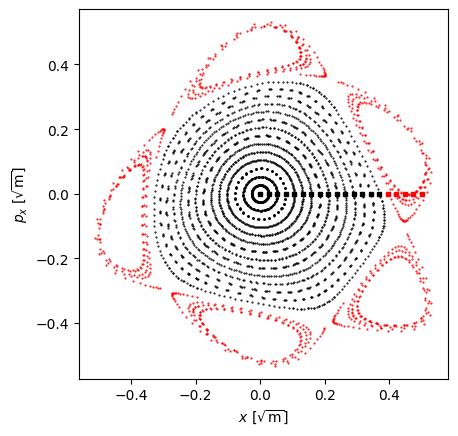

In [3]:
for tracking in tracking_list[0:15]:
    plt.plot(tracking['x'][0:200], tracking['px'][0:200], '.', color='k', markersize=1)
for tracking in tracking_list[15:]:
    plt.plot(tracking['x'][0:200], tracking['px'][0:200], '.', color='r', markersize=1)

for tracking in tracking_list[0:15]:
    plt.plot(tracking['x'][0], tracking['px'][0], 's', color='k', markersize=3)

for tracking in tracking_list[15:]:
    plt.plot(tracking['x'][0], tracking['px'][0], 's', color='r', markersize=3)
plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$ p_x\ [\sqrt{\mathrm{m}}]$');
plt.savefig('../plots/henon_map.pdf', dpi=300, bbox_inches='tight')

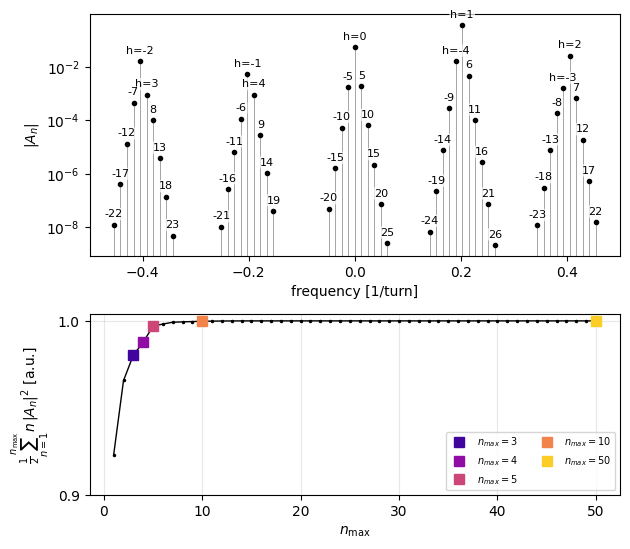

In [25]:
# Plotting the harmonic analysis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.4, 5.6),
                                gridspec_kw={'height_ratios': [4, 3]})

# ── Top panel: harmonic spectrum ──────────────────────────────────────────
ax1.semilogy(tracking_list[14]['Qx'], np.abs(tracking_list[14]['Ax']), '.', color='k', ms=6, alpha=1)
ymin = ax1.get_ylim()[0]
ax1.vlines(tracking_list[14]['Qx'], ymin, np.abs(tracking_list[14]['Ax']),
           colors='k', lw=0.5, alpha=0.5)
bbox_props = dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7, edgecolor='none')
for ii in range(50):
    if np.abs(tracking_list[14]['nx'][ii][0]) < 5:
        ax1.annotate('h=' + str(tracking_list[14]['nx'][ii][0]),
                     xy=(tracking_list[14]['Qx'][ii], np.abs(tracking_list[14]['Ax'][ii])),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontsize=8, bbox=bbox_props)
    else:
        ax1.annotate(str(tracking_list[14]['nx'][ii][0]),
                     xy=(tracking_list[14]['Qx'][ii], np.abs(tracking_list[14]['Ax'][ii])),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', va='bottom', fontsize=8, bbox=bbox_props)
ax1.set_xlim(-0.5, 0.5)
ax1.set_xlabel(r'frequency [1/turn]')
ax1.set_ylabel(r'$ |A_n|$')

# ── Bottom panel: 1/2 * Sum_{n=1}^{n_max} n |A_n|^2 vs n_max ─────────────
Ax = tracking_list[14]['Ax']
n_max_values = np.arange(1, 51)
action_sum = np.array([
    0.5 * np.sum([(n + 1) * np.abs(Ax[n])**2 for n in range(n_max)])
    for n_max in n_max_values
])
action_sum_norm = action_sum / action_sum[-1]

max_terms_list = [3, 4, 5, 10, 50]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(max_terms_list)))

ax2.semilogy(n_max_values, action_sum_norm, '.-', color='k', lw=1, ms=3)
for idx, n_max in enumerate(max_terms_list):
    ax2.semilogy(n_max, action_sum_norm[n_max - 1], 's', color=colors[idx],
                 ms=7, label=f'$n_{{max}}={n_max}$')

ax2.set_xlabel(r'$n_\mathrm{max}$')
ax2.set_ylabel(r'$\frac{1}{2} \sum_{n=1}^{n_\mathrm{max}} n\,|A_n|^2$ [a.u.]')
ax2.set_yticks([0.9, 1.0])
ax2.get_yaxis().set_major_formatter(plt.ScalarFormatter())
ax2.yaxis.set_minor_locator(plt.NullLocator())
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=7, ncol=2, loc='lower right')

plt.tight_layout()
plt.savefig('../plots/harmonic_analysis.pdf', dpi=300, bbox_inches='tight')

In [19]:
aux = []
for ii in tracking_list[14]['nx']:
    aux.append(ii[0])
np.sort(np.array(aux))

array([-24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12,
       -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,
         2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,  14,
        15,  16,  17,  18,  19,  20,  21,  22,  23,  25,  26], dtype=int16)

In [75]:
len (aux)

50

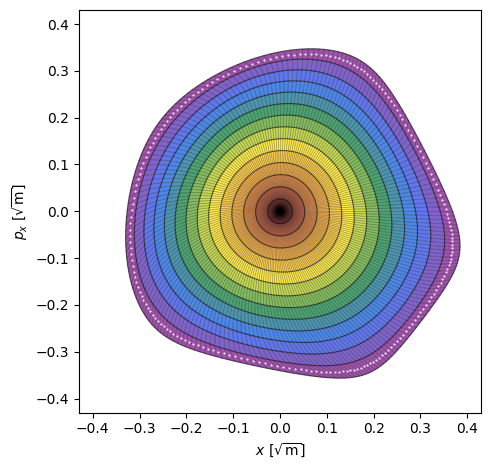

In [20]:
# Plotting the tori mesh NL
#--------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap

n_angles = 201
Tx = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

# Peace flag colormap (smooth gradient over the rings)
peace_colors = ['#E40303', '#FF8C00', '#FFED00', '#008026', '#004DFF', '#750787']
peace_cmap = LinearSegmentedColormap.from_list('peace', peace_colors)

tori_plot = tori[0:15]
Ix_list = [torus.Ix for torus in tori_plot]
n_rings = len(tori_plot) - 1

# Collect mesh node coordinates: shape (n_tori, n_angles)
X_mesh  = np.array([torus.X(Tx)  for torus in tori_plot])
PX_mesh = np.array([torus.PX(Tx) for torus in tori_plot])

fig, ax = plt.subplots()

# Fill each quadrilateral cell, color mapped by ring index
for i in range(n_rings):
    color = peace_cmap(i / (n_rings - 1))
    for j in range(n_angles):
        j1 = (j + 1) % n_angles
        quad_x  = [X_mesh[i, j],  X_mesh[i, j1],  X_mesh[i+1, j1],  X_mesh[i+1, j]]
        quad_px = [PX_mesh[i, j], PX_mesh[i, j1], PX_mesh[i+1, j1], PX_mesh[i+1, j]]
        ax.fill(quad_x, quad_px, color=color, alpha=0.7, linewidth=0)

# White dot at the center of each outermost ring cell
i_outer = n_rings - 1
for j in range(n_angles):
    j1 = (j + 1) % n_angles
    cx = 0.25 * (X_mesh[i_outer, j] + X_mesh[i_outer, j1] + X_mesh[i_outer+1, j1] + X_mesh[i_outer+1, j])
    cy = 0.25 * (PX_mesh[i_outer, j] + PX_mesh[i_outer, j1] + PX_mesh[i_outer+1, j1] + PX_mesh[i_outer+1, j])
    ax.plot(cx, cy, '.', color='white', ms=1, zorder=5)

# Rings on top
for torus in tori_plot:
    ptplt.xloop(torus, num_points=200, edgecolor='k', alpha=0.6, lw=0.8)

# Spokes on top
for j in range(n_angles):
    ax.plot(X_mesh[:, j], PX_mesh[:, j], color='k', lw=0.5, alpha=0.4)

ax.set_xlim(-0.43, 0.43)
ax.set_ylim(-0.43, 0.43)
ax.set_aspect('equal')
ax.set_box_aspect(1)
ax.set_xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$')
ax.set_ylabel(r'$ p_x\ [\sqrt{\mathrm{m}}]$')
plt.tight_layout()
plt.savefig('../plots/tori_mesh.pdf', dpi=600, bbox_inches='tight')

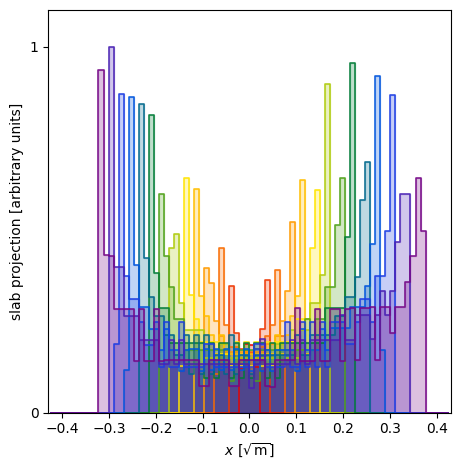

In [21]:
# x-projections of each torus slab (same color code as the mesh plot above)
# For slab i, each angular cell contributes its centroid-x weighted by cell
# area → area-weighted histogram; not normalised so integral ∝ slab area.
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots()

x_range   = (-0.43, 0.43)
n_bins    = 80
x_edges   = np.linspace(*x_range, n_bins + 1)
x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

j_arr  = np.arange(n_angles)
j1_arr = (j_arr + 1) % n_angles

hists = []
for i in range(n_rings):
    qx  = np.array([X_mesh[i,   j_arr],  X_mesh[i,   j1_arr],
                    X_mesh[i+1, j1_arr], X_mesh[i+1, j_arr]])
    qpx = np.array([PX_mesh[i,   j_arr],  PX_mesh[i,   j1_arr],
                    PX_mesh[i+1, j1_arr], PX_mesh[i+1, j_arr]])
    cx   = qx.mean(axis=0)
    area = 0.5 * np.abs(
        qx[0]*qpx[1] - qx[1]*qpx[0] +
        qx[1]*qpx[2] - qx[2]*qpx[1] +
        qx[2]*qpx[3] - qx[3]*qpx[2] +
        qx[3]*qpx[0] - qx[0]*qpx[3])
    hist, _ = np.histogram(cx, bins=x_edges, weights=area)
    hists.append(hist)

global_max = max(h.max() for h in hists)

for i, hist in enumerate(hists):
    color = peace_cmap(i / (n_rings - 1))
    hist_norm = hist / global_max
    ax.step(x_centers, hist_norm, where='mid', color=color, lw=1.2, alpha=0.9)
    ax.fill_between(x_centers, hist_norm, step='mid', color=color, alpha=0.25)

ax.set_xlim(*x_range)
ax.set_ylim(0, 1.1)
ax.set_yticks([0, 1])
ax.set_xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$')
ax.set_ylabel('slab projection [arbitrary units]')
ax.set_box_aspect(1)
plt.tight_layout()
plt.savefig('../plots/slab_projections_x.pdf', dpi=600, bbox_inches='tight')


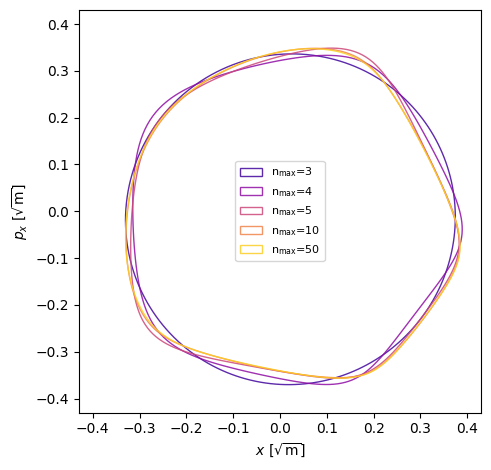

In [22]:
# Reference dimension cell
fig, ax = plt.subplots()

max_terms_list = [3, 4, 5, 10, 50]

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(max_terms_list)))
lw_values = np.linspace(1, 1, len(max_terms_list))

for idx, max_terms in enumerate(max_terms_list):
    new = torus.copy(max_terms=max_terms)
    ptplt.xloop(new, num_points=200, edgecolor=colors[idx], alpha=0.85,
                lw=lw_values[idx], label=f'n$_{{\\rm{{max}}}}$={max_terms}')

ax.set_xlim(-0.43, 0.43)
ax.set_ylim(-0.43, 0.43)
ax.set_aspect('equal')
ax.set_box_aspect(1)
ax.set_xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$')
ax.set_ylabel(r'$ p_x\ [\sqrt{\mathrm{m}}]$')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../plots/tori_approximation.pdf', dpi=600, bbox_inches='tight')


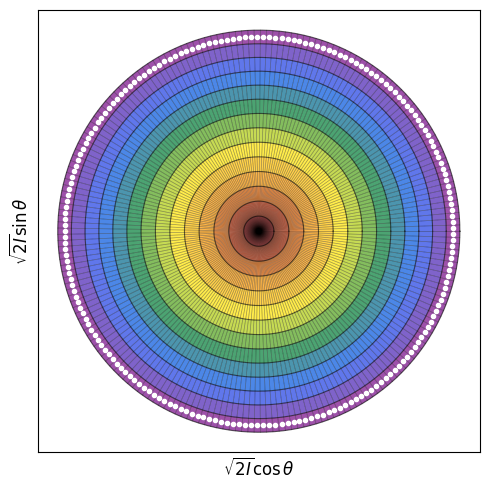

In [78]:
# Normalised mesh (action-angle coordinates: r=sqrt(2I), theta)
# Same color coding as physical mesh: corona i -> peace_cmap(i / (n_rings-1))
#--------------------------------------------------
from matplotlib.colors import LinearSegmentedColormap

peace_cmap = LinearSegmentedColormap.from_list('peace', peace_colors)
r_nodes = np.sqrt(2 * np.array([torus.Ix for torus in tori_plot]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')

for i in range(n_rings):
    color = peace_cmap(i / (n_rings - 1))
    for j in range(n_angles):
        j1 = (j + 1) % n_angles
        th = [Tx[j],       Tx[j1],       Tx[j1],       Tx[j]]
        r  = [r_nodes[i],  r_nodes[i],   r_nodes[i+1], r_nodes[i+1]]
        ax.fill(np.array(r)*np.cos(th), np.array(r)*np.sin(th),
                color=color, alpha=0.7, linewidth=0)

# White dot at center of each outermost cell
i_outer = n_rings - 1
for j in range(n_angles):
    j1 = (j + 1) % n_angles
    th = [Tx[j],            Tx[j1],            Tx[j1],             Tx[j]]
    r  = [r_nodes[i_outer], r_nodes[i_outer],  r_nodes[i_outer+1], r_nodes[i_outer+1]]
    cx = np.mean(np.array(r) * np.cos(th))
    cy = np.mean(np.array(r) * np.sin(th))
    ax.plot(cx, cy, 'o', color='white', ms=3, zorder=5)

theta_full = np.linspace(0, 2*np.pi, 300)
for r in r_nodes:
    ax.plot(r*np.cos(theta_full), r*np.sin(theta_full), 'k-', lw=0.8, alpha=0.6)
for j in range(n_angles):
    ax.plot([r_nodes[0]*np.cos(Tx[j]), r_nodes[-1]*np.cos(Tx[j])],
            [r_nodes[0]*np.sin(Tx[j]), r_nodes[-1]*np.sin(Tx[j])],
            'k-', lw=0.5, alpha=0.4)

# Mapped points (requires the mapping cell below to have been run first)
if 'mapped' in dir() and 'marker_colors' in dir():
    for (xn, yn, _, _), c in zip(mapped, marker_colors):
        if xn is not None:
            ax.plot(xn, yn, 'o', color=c, ms=8, zorder=6,
                    markeredgecolor='k', markeredgewidth=0.5)

ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(r'$\sqrt{2I}\cos\theta$', fontsize=12)
ax.set_ylabel(r'$\sqrt{2I}\sin\theta$', fontsize=12)
plt.tight_layout()

Point with physical coordinates (0.05, 0.18) is outside the mesh and cannot be mapped.
Point with physical coordinates (0.05, 0.18) is outside the mesh and cannot be mapped.
Point with physical coordinates (0.05, 0.18) is outside the mesh and cannot be mapped.
Point with physical coordinates (0.05, 0.18) is outside the mesh and cannot be mapped.
Point with physical coordinates (0.05, 0.18) is outside the mesh and cannot be mapped.


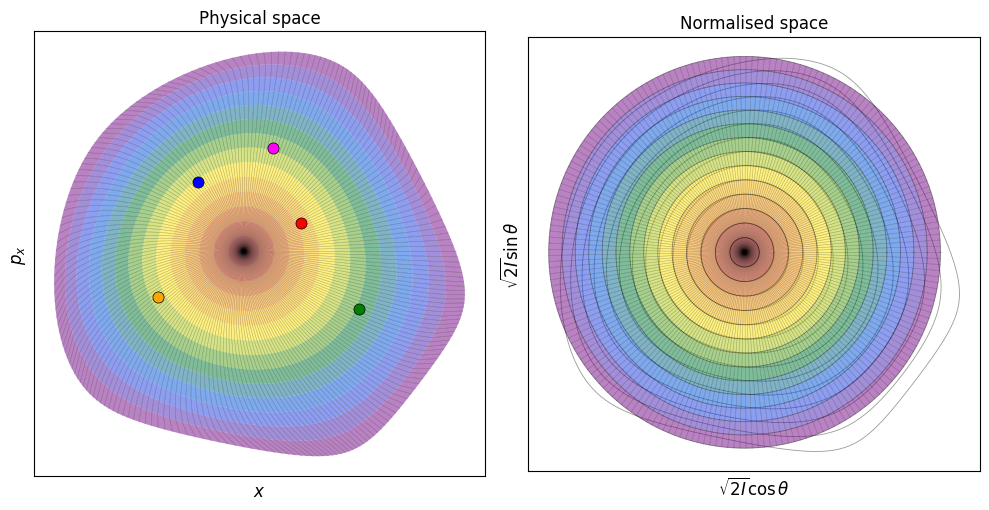

In [10]:
# Map arbitrary points from physical (x,px) to normalised (action-angle) space
# via bilinear interpolation on the symplectic mesh
# ─────────────────────────────────────────────────────────────────────────────

def point_in_quad(x, px, qx, qpx):
    """True if (x,px) is inside the convex quadrilateral (cross-product sign test)."""
    signs = []
    n = len(qx)
    for k in range(n):
        x1, y1 = qx[k],       qpx[k]
        x2, y2 = qx[(k+1)%n], qpx[(k+1)%n]
        signs.append((x2-x1)*(px-y1) - (y2-y1)*(x-x1))
    s = np.array(signs)
    return bool(np.all(s >= 0) or np.all(s <= 0))

def bilinear_uv(x, px, P00, P10, P01, P11):
    """Solve (u,v) in [0,1]^2 via Newton iteration."""
    u, v = 0.5, 0.5
    for _ in range(30):
        Puv  = (1-u)*(1-v)*P00 + u*(1-v)*P10 + (1-u)*v*P01 + u*v*P11
        dPdu = -(1-v)*P00 + (1-v)*P10 - v*P01 + v*P11
        dPdv = -(1-u)*P00 - u*P10 + (1-u)*P01 + u*P11
        J    = np.array([[dPdu[0], dPdv[0]], [dPdu[1], dPdv[1]]])
        res  = Puv - np.array([x, px])
        if np.linalg.norm(res) < 1e-14:
            break
        delta = np.linalg.solve(J, res)
        u -= delta[0]; v -= delta[1]
    return u, v

def map_to_normalised(x, px):
    """Return normalised-space (xn, yn) and cell (i,j) for point (x,px)."""
    for i in range(n_rings):
        for j in range(n_angles):
            j1  = (j + 1) % n_angles
            qx  = [X_mesh[i,j],  X_mesh[i+1,j],  X_mesh[i,j1],  X_mesh[i+1,j1]]
            qpx = [PX_mesh[i,j], PX_mesh[i+1,j], PX_mesh[i,j1], PX_mesh[i+1,j1]]
            if point_in_quad(x, px, qx, qpx):
                P00 = np.array([X_mesh[i,   j],  PX_mesh[i,   j]])
                P10 = np.array([X_mesh[i+1, j],  PX_mesh[i+1, j]])
                P01 = np.array([X_mesh[i,   j1], PX_mesh[i,   j1]])
                P11 = np.array([X_mesh[i+1, j1], PX_mesh[i+1, j1]])
                u, v = bilinear_uv(x, px, P00, P10, P01, P11)
                N00 = np.array([r_nodes[i]  *np.cos(Tx[j]),  r_nodes[i]  *np.sin(Tx[j])])
                N10 = np.array([r_nodes[i+1]*np.cos(Tx[j]),  r_nodes[i+1]*np.sin(Tx[j])])
                N01 = np.array([r_nodes[i]  *np.cos(Tx[j1]), r_nodes[i]  *np.sin(Tx[j1])])
                N11 = np.array([r_nodes[i+1]*np.cos(Tx[j1]), r_nodes[i+1]*np.sin(Tx[j1])])
                Pn  = (1-u)*(1-v)*N00 + u*(1-v)*N10 + (1-u)*v*N01 + u*v*N11
                return Pn[0], Pn[1], i, j
    return None, None, None, None

# ── Test points ───────────────────────────────────────────────────────────────
test_points = [
    ( 0.10,  0.05),
    (-0.08,  0.12),
    ( 0.20, -0.10),
    (-0.15, -0.08),
    ( 0.05,  0.18),
]
marker_colors = ['red', 'blue', 'green', 'orange', 'magenta']
mapped = [map_to_normalised(x, px) for x, px in test_points]

# ── Plot ──────────────────────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
peace_cmap = LinearSegmentedColormap.from_list('peace', peace_colors)
theta_full = np.linspace(0, 2*np.pi, 300)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5))

# ── Panel 0: physical (x, px) ────────────────────────────────────────────────
ax0.set_aspect('equal')
for i in range(n_rings):
    color = peace_cmap(i / (n_rings - 1))
    for j in range(n_angles):
        j1 = (j+1) % n_angles
        ax0.fill([X_mesh[i,j], X_mesh[i,j1], X_mesh[i+1,j1], X_mesh[i+1,j]],
                 [PX_mesh[i,j],PX_mesh[i,j1],PX_mesh[i+1,j1],PX_mesh[i+1,j]],
                 color=color, alpha=0.5, linewidth=0)
for torus in tori_plot:
    ptplt.xloop(torus, num_points=200, edgecolor='k', alpha=0.4, lw=0.6)
for j in range(n_angles):
    ax0.plot(X_mesh[:,j], PX_mesh[:,j], 'k-', lw=0.4, alpha=0.3)
for (x, px), c in zip(test_points, marker_colors):
    ax0.plot(x, px, 'o', color=c, ms=8, zorder=6, markeredgecolor='k', markeredgewidth=0.5)
ax0.set_xticks([]); ax0.set_yticks([])
ax0.set_xlabel(r'$x$', fontsize=12); ax0.set_ylabel(r'$p_x$', fontsize=12)
ax0.set_title('Physical space')

# ── Panel 1: normalised Cartesian ────────────────────────────────────────────
ax1.set_aspect('equal')
for i in range(n_rings):
    color = peace_cmap(i / (n_rings - 1))
    for j in range(n_angles):
        j1 = (j+1) % n_angles
        th = [Tx[j], Tx[j1], Tx[j1], Tx[j]]
        r  = [r_nodes[i], r_nodes[i], r_nodes[i+1], r_nodes[i+1]]
        ax1.fill(np.array(r)*np.cos(th), np.array(r)*np.sin(th),
                 color=color, alpha=0.5, linewidth=0)
for r in r_nodes:
    ax1.plot(r*np.cos(theta_full), r*np.sin(theta_full), 'k-', lw=0.6, alpha=0.4)
for j in range(n_angles):
    ax1.plot([r_nodes[0]*np.cos(Tx[j]), r_nodes[-1]*np.cos(Tx[j])],
             [r_nodes[0]*np.sin(Tx[j]), r_nodes[-1]*np.sin(Tx[j])],
             'k-', lw=0.4, alpha=0.3)
for (xn, yn, _, _), c in zip(mapped, marker_colors):
    if xn is not None:
        ax1.plot(xn, yn, 'o', color=c, ms=8, zorder=6,
                 markeredgecolor='k', markeredgewidth=0.5)
    else:
        print(f'Point with physical coordinates ({x}, {px}) is outside the mesh and cannot be mapped.')
ax1.set_xticks([]); ax1.set_yticks([])
ax1.set_xlabel(r'$\sqrt{2I}\cos\theta$', fontsize=12)
ax1.set_ylabel(r'$\sqrt{2I}\sin\theta$', fontsize=12)
ax1.set_title('Normalised space')

plt.tight_layout()

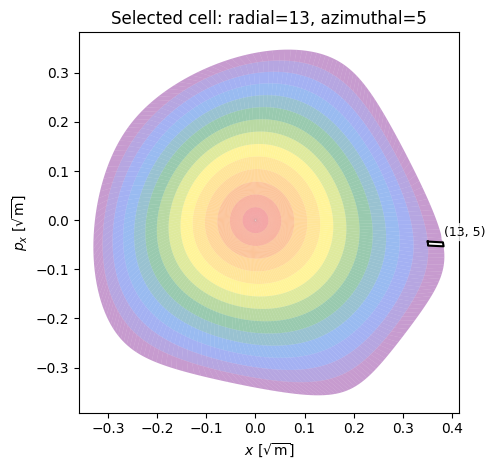

In [11]:
# Mesh coordinate system: cell (i_rad, i_ang)
#   i_rad : radial corona   index, 0 = innermost,  n_rings-1 = outermost
#   i_ang : azimuthal angle index, 0 = first slice, n_angles-1 = last slice
# X_mesh, PX_mesh and n_angles must already be defined (run the cell above first)

def get_cell_corners(i_rad, i_ang):
    """Return the 4 corners of cell (i_rad, i_ang) as (x_corners, px_corners)."""
    j1 = (i_ang + 1) % n_angles
    x  = [X_mesh[i_rad,   i_ang], X_mesh[i_rad,   j1],
          X_mesh[i_rad+1, j1],    X_mesh[i_rad+1, i_ang]]
    px = [PX_mesh[i_rad,   i_ang], PX_mesh[i_rad,   j1],
          PX_mesh[i_rad+1, j1],    PX_mesh[i_rad+1, i_ang]]
    return np.array(x), np.array(px)

def get_cell_center(i_rad, i_ang):
    """Return the centroid of cell (i_rad, i_ang)."""
    x, px = get_cell_corners(i_rad, i_ang)
    return x.mean(), px.mean()

# ── Example: highlight cell (4, 5) ──────────────────────────────────────────
i_rad_sel, i_ang_sel = 13, 5

fig, ax = plt.subplots()

# Draw full mesh (light background)
from matplotlib.colors import LinearSegmentedColormap
peace_cmap = LinearSegmentedColormap.from_list('peace', peace_colors)
for i in range(n_rings):
    color = peace_cmap(i / (n_rings - 1))
    for j in range(n_angles):
        xc, pxc = get_cell_corners(i, j)
        ax.fill(xc, pxc, color=color, alpha=0.4, linewidth=0)

# Highlight the selected cell
xc, pxc = get_cell_corners(i_rad_sel, i_ang_sel)
ax.fill(xc, pxc, color='white', alpha=1.0, linewidth=0, zorder=3)
ax.plot(np.append(xc, xc[0]), np.append(pxc, pxc[0]),
        'k-', lw=1.5, zorder=4)

# Mark centroid
cx, cy = get_cell_center(i_rad_sel, i_ang_sel)
#ax.plot(cx, cy, 'ko', ms=5, zorder=5)
ax.annotate(f'({i_rad_sel}, {i_ang_sel})', xy=(cx, cy),
            xytext=(6, 6), textcoords='offset points', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

ax.set_aspect('equal')
ax.set_box_aspect(1)
ax.set_xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$')
ax.set_ylabel(r'$ p_x\ [\sqrt{\mathrm{m}}]$')
ax.set_title(f'Selected cell: radial={i_rad_sel}, azimuthal={i_ang_sel}')
plt.tight_layout()

Corona 1:
  mean / (dI dtheta) = 0.999837
  std/mean           = 1.51e-03


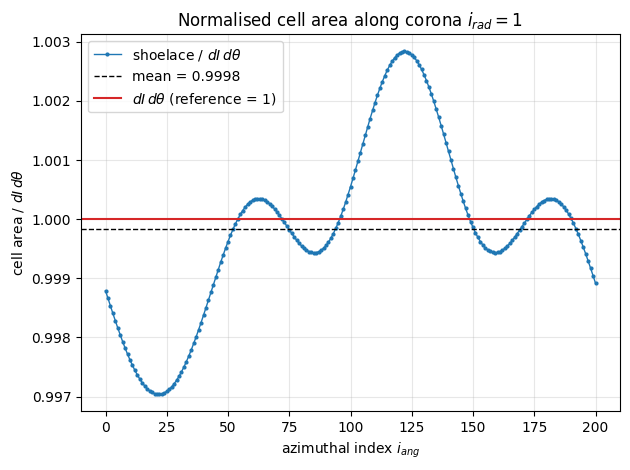

In [12]:
# Area of each cell in corona i_rad_sel=13 vs azimuthal index
i_rad_sel = 1

def cell_area(i_rad, i_ang):
    """Area of cell (i_rad, i_ang) via shoelace formula."""
    x, px = get_cell_corners(i_rad, i_ang)
    x  = np.append(x,  x[0])
    px = np.append(px, px[0])
    return 0.5 * np.abs(np.dot(x[:-1], px[1:]) - np.dot(x[1:], px[:-1]))

areas = np.array([cell_area(i_rad_sel, j) for j in range(n_angles)])

# Analytical polar estimate: r dr dtheta = dI * dtheta
dI         = tori_plot[i_rad_sel + 1].Ix - tori_plot[i_rad_sel].Ix
dtheta     = 2 * np.pi / n_angles
area_polar = dI * dtheta

# Normalize to area_polar
areas_norm = areas / area_polar

fig, ax = plt.subplots()
ax.plot(np.arange(n_angles), areas_norm, '.-', color='C0', lw=1, ms=4, label='shoelace / $dI\,d\\theta$')
ax.axhline(areas_norm.mean(), color='k',  lw=1,   ls='--', label=f'mean = {areas_norm.mean():.4f}')
ax.axhline(1.0,               color='C3', lw=1.5, ls='-',  label='$dI\,d\\theta$ (reference = 1)')
ax.set_xlabel('azimuthal index $i_{{ang}}$')
ax.set_ylabel('cell area / $dI\,d\\theta$')
ax.set_title(f'Normalised cell area along corona $i_{{rad}}={i_rad_sel}$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

print(f'Corona {i_rad_sel}:')
print(f'  mean / (dI dtheta) = {areas_norm.mean():.6f}')
print(f'  std/mean           = {areas_norm.std()/areas_norm.mean():.2e}')

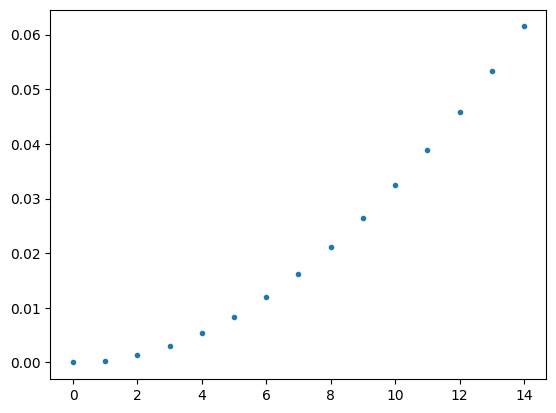

In [13]:
plt.plot(Ix_list, '.', color='C0', ms=6)


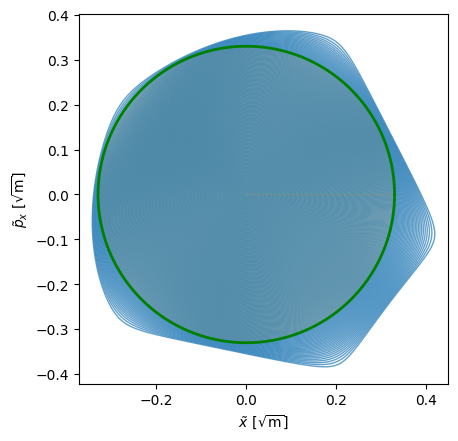

In [14]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

# =======================
# Mesh parameters
x_tori_number = 199
#x_start = np.linspace(0.0001,0.328,x_tori_number)
x_start = np.linspace(0.00001,0.328,x_tori_number)

angular_points_number = 500
# ======================

# ========================
# Henon parameters
num_turns   = int(0.5e4)
Q0          = 0.2071
# ========================


# Generating tori
px_start   = 0.37 * x_start

tori    = []
for x0, px0 in zip(x_start, px_start):
    # Iterating Henon map
    x, px   = nafflib.henon_map(x0, px0, Q0, num_turns)

    # Extracting harmonics:
    #============================================================================
    n_harm  = 50
    w_order = 4
    Ax,Qx   = nafflib.harmonics(x,px,num_harmonics = n_harm,window_order=w_order)
    #============================================================================

    # Indexing harmonics
    #============================================================================
    max_n       = 90 #(high numbers needed in 2D..)
    max_alias   = 50
    warning_tol = np.inf #Disable warnings
    Qvec    = [Qx[0]]
    nx      = nafflib.linear_combinations(Qx,Qvec = Qvec,max_n=max_n,max_alias=max_alias,warning_tol=warning_tol)
    #============================================================================

    # Building torus (2D-torus)
    #============================================================================
    _torus = pt.Torus.from_naff(n=[nx],A=[Ax])
    tori.append(_torus)
    #============================================================================


# Plotting
#--------------------------------------------------

# %%

plt.figure()
for torus in tori:
    # Full loop around 0-2pi
    ptplt.xloop(torus,num_points=200,edgecolor='C0',alpha=0.7,lw=1)

    # Free hand plot of the torus
    Tx = np.linspace(0-np.pi/8,2*np.pi-np.pi/8,50) # Theta_x values
    #plt.plot(torus.X(Tx), torus.PX(Tx),'-',color='C3',lw=1)
    #plt.plot(torus.X(Tx[0]), torus.PX(Tx[0]),'o',color='C3',ms=3)
    #plt.plot(torus.X(Tx[:-1]), torus.PX(Tx[:-1]),'-',color='C3',ms=3.5,alpha=0.2)




plt.axis('equal')
plt.gca().set_box_aspect(1) 
plt.xlabel(r'$\tilde x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$\tilde p_x\ [\sqrt{\mathrm{m}}]$');

# plot an annulus from 0.1 to 0.3
annulus_inner = 0
annulus_outer = 0.33
theta = np.linspace(0, 2 * np.pi, angular_points_number)
# outer circle
x_outer = annulus_outer * np.cos(theta[::-1])
px_outer = annulus_outer * np.sin(theta[::-1])

# inner circle (reverse direction to make a proper closed annulus)
x_inner = annulus_inner * np.cos(theta)
px_inner = annulus_inner * np.sin(theta)
  
plt.plot(x_inner, px_inner, 'g',lw=2,label='Inner Annulus')
plt.plot(x_outer, px_outer, 'g',lw=2,label='Outer Annulus')

x = np.concatenate([x_outer, x_inner])
y = np.concatenate([px_outer, px_inner])

plt.fill(x, y, color='orange', alpha=.1)
plt.gca().set_aspect('equal')
plt.show()

### Important observation

We observe that two particle belonging to the same torus positioned at $d\theta$, keep their  $d\theta$ during the rotation BUT their $dl$ along the torus is changing. To be noted that the smaller the radius of curvature of the torus, the smaller the $dl$ at constant $d\theta$.

The above information implies, that if the torus is not a circle then the matched density of the torus in not $dl$-constant along the torus. It is higher when the radius of curvature is smaller. In other words, the matched density of the torus should be $d\theta$-constant (e.g., invariant by rotation). 

(-0.3806916184990112,
 0.45747013416576765,
 -0.4205273635741384,
 0.4016538973654367)

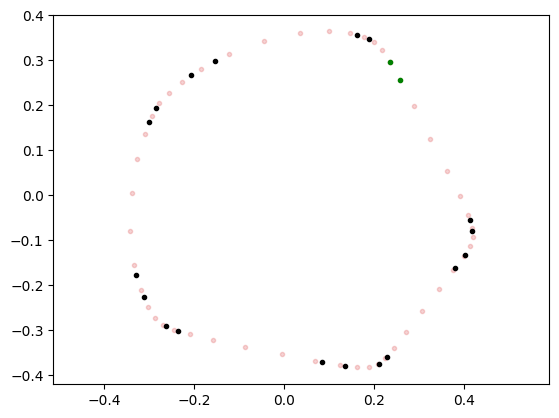

In [15]:
plt.plot(torus.X(Tx), torus.PX(Tx),'o',color='C3',ms=3, alpha=0.2)
plt.plot(torus.X(Tx[0]), torus.PX(Tx[0]),'o',color='g',ms=3)
plt.plot(torus.X(Tx[1]), torus.PX(Tx[1]),'o',color='g',ms=3)

x0 = torus.X(Tx[0])
px0 = torus.PX(Tx[0])
x1, px1   = nafflib.henon_map(x0, px0, Q0, num_turns=200)

x0 = torus.X(Tx[1])
px0 = torus.PX(Tx[1])
x2, px2   = nafflib.henon_map(x0, px0, Q0, num_turns=200)

plt.plot(x1[-5:], px1[-5:], 'ko',ms=3)
plt.plot(x2[-5:], px2[-5:], 'ko',ms=3)

plt.plot(x1[1:5], px1[1:5], 'ko',ms=3)
plt.plot(x2[1:5], px2[1:5], 'ko',ms=3)
plt.axis('equal')

### Meshing the phase space

For our objective, we cannot simply sample the phase space but mesh it. The mesh grid will be defined by the discrete sequence of actions (tori) and angles. 
Each node of the mesh needs to be weighted by the area attached to the node. The mesh we use is homothetic to a polar grid (normal form) but we operate on the physical linear normalized space. For semplicity we use the number of angles considered is J-independent (4-node quadrilateral mesh). In other words the weight of the node is something similar to $rdr\theta$, the elementary area in polar coordinates. 

In [16]:
import numpy as np

def annulus(x, y, annulus_inner, annulus_outer):
    # Convert to numpy arrays (no effect if they are already arrays)
    x = np.asarray(x)
    y = np.asarray(y)

    r2 = x**2 + y**2
    return np.where((annulus_inner**2 <= r2) & (r2 <= annulus_outer**2), 1, 0)

def area_quadrilateral(x1, px1, x2, px2, x3, px3, x4, px4):
    # split into two triangles
    area1 = 0.5 * np.abs(x1*(px2 - px3) + x2*(px3 - px1) + x3*(px1 - px2))
    area2 = 0.5 * np.abs(x1*(px3 - px4) + x3*(px4 - px1) + x4*(px1 - px3))
    return area1 + area2 

def annulus_weighted(Q, P, annulus_inner, annulus_outer):
    """
    Evaluate annulus membership and weight by distance between consecutive points.
    
    Parameters:
    -----------
    Q : np.array
        Array of Q coordinates (shape: N)
    P : np.array  
        Array of P coordinates (shape: N)
    annulus_inner : float
        Inner radius of annulus
    annulus_outer : float
        Outer radius of annulus
        
    Returns:
    --------
    weights : np.array
        Array of weights for each point. Points outside annulus get weight 0.
        Points inside annulus get weight proportional to distance from previous point.
    """
    Q = np.asarray(Q)
    P = np.asarray(P)
    
   
    
    # Binary mask for points in annulus
    value = annulus(Q, P, annulus_inner, annulus_outer)
    
    
    
    # Calculate distances between consecutive points
    area = 1
    for ii in range(1,x_tori_number):
        for jj in range(angular_points_number-1):
            area = 1
    #        area = 1 #area_quadrilateral(x[ii-1,jj-1], px[ii-1,jj-1],
                        #   x[ii-1,jj], px[ii-1,jj],
                        #   x[ii,jj], px[ii,jj],
                        #   x[ii,jj-1], px[ii,jj-1]))
    # Weight by distance, but only for points in annulus
    weights = value * area
    
    return weights

def gaussian_2d(x, y, sigma, truncation_sigma=3.0):
    """
    Isotropic 2D Gaussian evaluated at (x, y), truncated to 0 beyond
    truncation_sigma * sigma.  Analogous to annulus() but returns a
    continuous density value instead of a binary mask.

    Parameters
    ----------
    x, y            : coordinates (scalar or array)
    sigma           : Gaussian sigma [same units as x, y]
    truncation_sigma: hard cut-off radius in units of sigma (default 3)
    """
    x = np.asarray(x)
    y = np.asarray(y)
    r2     = x**2 + y**2
    r2_max = (truncation_sigma * sigma)**2
    value  = np.exp(-r2 / (2.0 * sigma**2))
    return np.where(r2 <= r2_max, value, 0.0)


def gaussian_2d_weighted(Q, P, sigma, truncation_sigma=3.0):
    """
    Weight each mesh cell by the truncated 2D Gaussian density times the
    cell area.  Analogous to the annulus inline loop, but for a Gaussian
    distribution.

    Parameters
    ----------
    Q, P             : mesh coordinate arrays, shape (x_tori_number, n_ang)
    sigma            : Gaussian sigma
    truncation_sigma : hard cut-off radius in units of sigma (default 3)

    Returns
    -------
    weights_g : array of shape (x_tori_number, n_ang)
    """
    Q = np.asarray(Q)
    P = np.asarray(P)
    n_tori, n_ang = Q.shape
    weights_g = np.zeros_like(Q)
    for ii in range(1, n_tori):
        for jj in range(n_ang):
            value = gaussian_2d(Q[ii, jj], P[ii, jj], sigma, truncation_sigma)
            area  = area_quadrilateral(
                Q[ii-1, jj-1], P[ii-1, jj-1],
                Q[ii-1, jj],   P[ii-1, jj],
                Q[ii,   jj],   P[ii,   jj],
                Q[ii,   jj-1], P[ii,   jj-1])
            weights_g[ii, jj] = value * area
    return weights_g


my_Q = []
my_P = []
my_density = []
my_average_density = []

for torus in tori: 
    looping = 'x'
    Tx = np.linspace(0,2*np.pi,angular_points_number) 
    Q = torus.X(Tx)
    P = torus.PX(Tx)

    my_Q.append(Q[:-1])
    my_P.append(P[:-1])  
    density = annulus_weighted(Q[:-1], P[:-1], annulus_inner, annulus_outer)
    my_density.append(density)
    average_density = np.mean(density)
    my_average_density.append(average_density*np.ones_like(Q[:-1]))

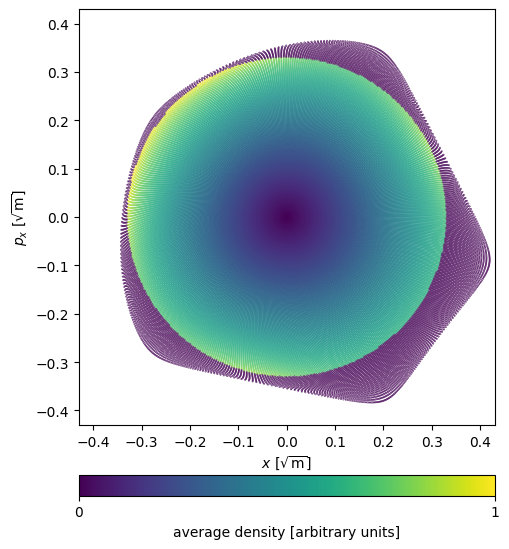

In [17]:


# ── Mesh construction ──────────────────────────────────────────────────────
my_Q = []
my_P = []

for torus in tori:
    Tx = np.linspace(0, 2*np.pi, angular_points_number)
    Q_t = torus.X(Tx)
    P_t = torus.PX(Tx)
    my_Q.append(Q_t[:-1])
    my_P.append(P_t[:-1])

Q = np.reshape(my_Q, (x_tori_number, angular_points_number-1))
P = np.reshape(my_P, (x_tori_number, angular_points_number-1))

# ── Annulus weights (binary mask × cell area) ──────────────────────────────
weights = np.zeros_like(Q)
values  = np.zeros_like(Q)

for ii in range(1, x_tori_number):
    for jj in range(angular_points_number-1):
        value = annulus(Q[ii, jj], P[ii, jj], annulus_inner, annulus_outer)
        area  = area_quadrilateral(Q[ii-1, jj-1], P[ii-1, jj-1],
                                   Q[ii-1, jj],   P[ii-1, jj],
                                   Q[ii,   jj],   P[ii,   jj],
                                   Q[ii,   jj-1], P[ii,   jj-1])
        values[ii, jj]  = value
        weights[ii, jj] = value * area

# ── Plot ───────────────────────────────────────────────────────────────────
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(6.4, 5.6))
sc = ax.scatter(Q, P, c=weights, cmap='viridis', marker='o', s=.1,
                vmin=weights.min(), vmax=weights.max())
ax.set_xlim(-0.43, 0.43)
ax.set_ylim(-0.43, 0.43)
ax.set_aspect('equal')
ax.set_box_aspect(1)
ax.set_xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$')
ax.set_ylabel(r'$ p_x\ [\sqrt{\mathrm{m}}]$')

average_weights = np.mean(weights, axis=1)
average_weights = np.repeat(average_weights[:, np.newaxis], angular_points_number-1, axis=1)

divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.5)
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal',
                    label='average density [arbitrary units]')
cbar.set_ticks([weights.min(), weights.max()])
cbar.set_ticklabels(['0', '1'])
plt.tight_layout()
plt.savefig('../plots/average_density.png', dpi=300, bbox_inches='tight')


/tmp/ipykernel_1559182/3624540634.py:13: UserWarning: Adding colorbar to a different Figure <Figure size 640x560 with 2 Axes> than <Figure size 640x560 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc, cax=cax, orientation='horizontal',


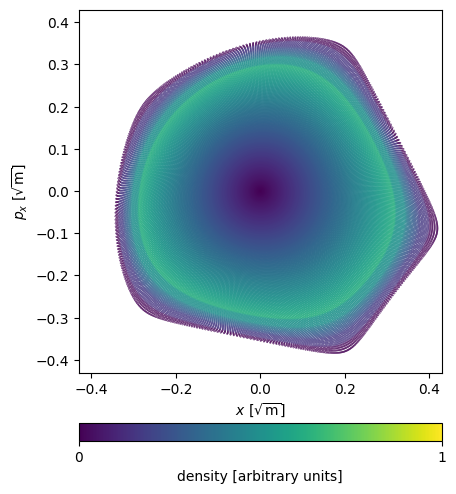

In [18]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.scatter(my_Q, my_P, c=average_weights, cmap='viridis',  marker='o',vmin=weights.min(), vmax=weights.max(), s=.1)
# plt.title('After filamentation')
plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$p_x\  [\sqrt{\mathrm{m}}]$')
ax = plt.gca()
ax.set_xlim(-0.43, 0.43)
ax.set_ylim(-0.43, 0.43)
ax.set_aspect('equal')
ax.set_box_aspect(1)
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.5)
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal',
                    label='density [arbitrary units]')
cbar.set_ticks([weights.min(), weights.max()])
cbar.set_ticklabels(['0', '1'])
plt.savefig('../plots/average_density_filamented.png', dpi=300, bbox_inches='tight')

### We compute the x-projection

It is important to observe/verify that the initial profile is the statistical projection of the initial distribution (no mesh aberration).

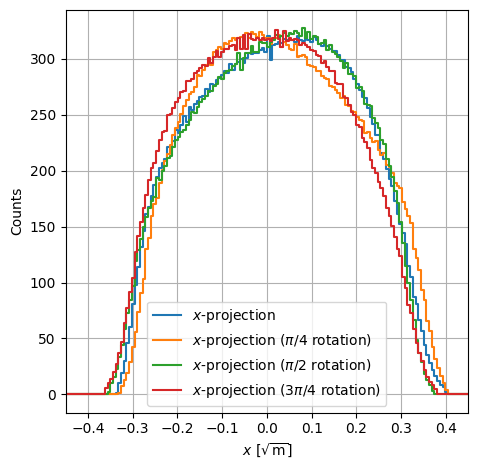

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Example arrays
# X, Y, W are 1D arrays of the same length
# X = ...
# Y = ...
# W = ...

# Bin definitions
my_Q_aux = np.concatenate(Q)
my_P_aux = np.concatenate(P)
my_average_density_aux = np.concatenate(average_weights)

steps = 150
xbins = np.linspace(min(my_Q_aux), max(my_Q_aux), steps)
ybins = np.linspace(min(my_P_aux), max(my_P_aux), steps)

# Build 2D weighted histogram
H, xedges, yedges = np.histogram2d(my_Q_aux, my_P_aux, bins=[xbins, ybins], weights=my_average_density_aux)

# Projection on X: sum over Y bins
projXX = H.sum(axis=1)

# Projection on Y: sum over X bins
projYY = H.sum(axis=0)

# Plot projections

#plt.step(xedges[:-1], projXX, where='mid')


my_Q_aux = np.concatenate(Q)
my_P_aux = np.concatenate(P)
my_density_aux = np.concatenate(weights)
xbins = np.linspace(-0.45, 0.45, steps)
ybins = np.linspace(-0.45, 0.45, steps)

# Build 2D weighted histogram
H, xedges, yedges = np.histogram2d(my_Q_aux, my_P_aux, bins=[xbins, ybins], weights=my_density_aux)

# Projection on X: sum over Y bins
projX = H.sum(axis=1)

# Projection on Y: sum over X bins
projY = H.sum(axis=0)

rotations = [
    (0,           r'$x$-projection'),
    (np.pi/4,     r'$x$-projection ($\pi/4$ rotation)'),
    (np.pi/2,     r'$x$-projection ($\pi/2$ rotation)'),
    (3*np.pi/4,   r'$x$-projection ($3\pi/4$ rotation)'),
]
proj_list = []
for theta, label in rotations:
    QQ = Q*np.cos(theta) - P*np.sin(theta)
    PP = Q*np.sin(theta) + P*np.cos(theta)
    H, xedges, _ = np.histogram2d(np.concatenate(QQ), np.concatenate(PP),
                                   bins=[xbins, ybins], weights=my_average_density_aux, density=True)
    proj_list.append((H.sum(axis=1), label))


# Plot projections
x_centers = xedges[1:]
for proj, label in proj_list:
    plt.step(x_centers, proj, where='mid', label=label)
    
# Abel transform of a uniform disk of radius annulus_outer
R = annulus_outer
x_abel = np.linspace(-R, R, 1000)
p_abel = 2 * np.sqrt(np.maximum(R**2 - x_abel**2, 0))
# Normalise to the same integral as the filamented projection
norm = np.trapz(proj_list[0][0], x_centers) / np.trapz(p_abel, x_abel)
#plt.plot(x_abel, p_abel * norm, 'k--', lw=1.5, label=r'Analytical $x$-projection (Abel transform)')

# plt.title("Projection on X")
# plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
# plt.ylabel("Weighted counts")

# plt.tight_layout()
# plt.grid()
# plt.legend()

plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
plt.ylabel("Counts")
plt.tight_layout()
plt.grid()
plt.legend()
plt.xlim(-0.45, 0.45)
ax = plt.gca()
ax.set_box_aspect(1)
plt.savefig('../plots/projection_x_final.pdf', dpi=300, bbox_inches='tight')


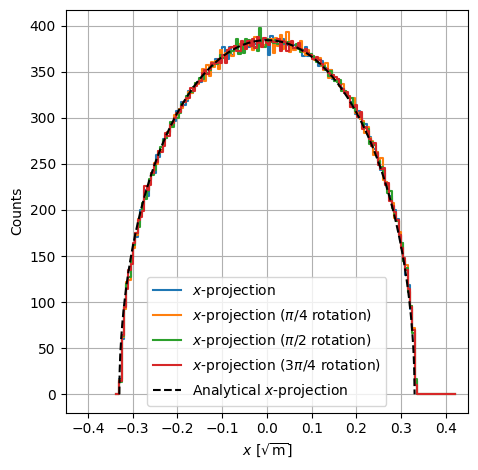

In [20]:
import numpy as np
import matplotlib.pyplot as plt

my_Q_aux = np.concatenate(Q)
my_P_aux = np.concatenate(P)
my_density_aux = np.concatenate(weights)

steps = 150
xbins = np.linspace(min(my_Q_aux), max(my_Q_aux), steps)
ybins = np.linspace(min(my_P_aux), max(my_P_aux), steps)

rotations = [
    (0,           r'$x$-projection'),
    (np.pi/4,     r'$x$-projection ($\pi/4$ rotation)'),
    (np.pi/2,     r'$x$-projection ($\pi/2$ rotation)'),
    (3*np.pi/4,   r'$x$-projection ($3\pi/4$ rotation)'),
]

proj_list = []
for theta, label in rotations:
    QQ = Q*np.cos(theta) - P*np.sin(theta)
    PP = Q*np.sin(theta) + P*np.cos(theta)
    H, xedges, _ = np.histogram2d(np.concatenate(QQ), np.concatenate(PP),
                                   bins=[xbins, ybins], weights=my_density_aux, density=True)
    proj_list.append((H.sum(axis=1), label))

x_centers = xedges[1:]
for proj, label in proj_list:
    plt.step(x_centers, proj, where='mid', label=label)

# Abel transform of a uniform disk of radius annulus_outer
R = annulus_outer
x_abel = np.linspace(-R, R, 1000)
p_abel = 2 * np.sqrt(np.maximum(R**2 - x_abel**2, 0))
# Normalise to the same integral as the 0-deg projection
norm = np.trapz(proj_list[0][0], x_centers) / np.trapz(p_abel, x_abel)
plt.plot(x_abel, p_abel * norm, 'k--', lw=1.5, label=r'Analytical $x$-projection')

# plt.title("Projection on X")
plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
plt.ylabel("Counts")
plt.tight_layout()
plt.grid()
plt.legend()
plt.xlim(-0.45, 0.45)
ax = plt.gca()
ax.set_box_aspect(1)
plt.savefig('../plots/projection_x_initial.pdf', dpi=300, bbox_inches='tight')


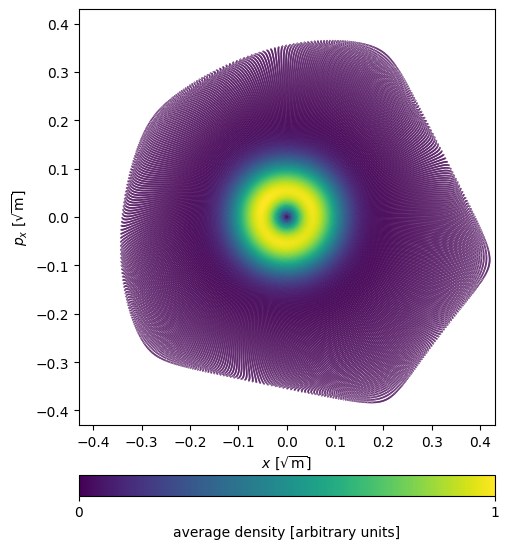

In [65]:
# ── Mesh construction ──────────────────────────────────────────────────────
my_Q = []
my_P = []

for torus in tori:
    Tx = np.linspace(0, 2*np.pi, angular_points_number)
    Q_t = torus.X(Tx)
    P_t = torus.PX(Tx)
    my_Q.append(Q_t[:-1])
    my_P.append(P_t[:-1])

Q = np.reshape(my_Q, (x_tori_number, angular_points_number-1))
P = np.reshape(my_P, (x_tori_number, angular_points_number-1))

# ── Gaussian weights (density × cell area) ────────────────────────────────
weights = np.zeros_like(Q)
values  = np.zeros_like(Q)

alpha =0.5
for ii in range(1, x_tori_number):
    for jj in range(angular_points_number-1):
        #value = gaussian_2d(Q[ii, jj], P[ii, jj], sigma=0.11*alpha, truncation_sigma=3.0/alpha)
        value = gaussian_2d(Q[ii, jj], P[ii, jj], sigma=0.055, truncation_sigma=6)
        area  = area_quadrilateral(Q[ii-1, jj-1], P[ii-1, jj-1],
                                   Q[ii-1, jj],   P[ii-1, jj],
                                   Q[ii,   jj],   P[ii,   jj],
                                   Q[ii,   jj-1], P[ii,   jj-1])
        values[ii, jj]  = value
        weights[ii, jj] = value * area

# ── Plot ───────────────────────────────────────────────────────────────────
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(6.4, 5.6))
sc = ax.scatter(Q, P, c=weights, cmap='viridis', marker='o', s=.1,
                vmin=weights.min(), vmax=weights.max())
ax.set_xlim(-0.43, 0.43)
ax.set_ylim(-0.43, 0.43)
ax.set_aspect('equal')
ax.set_box_aspect(1)
ax.set_xlabel(r'$ x\ [\sqrt{\mathrm{m}}]$')
ax.set_ylabel(r'$ p_x\ [\sqrt{\mathrm{m}}]$')

average_weights = np.mean(weights, axis=1)
average_weights = np.repeat(average_weights[:, np.newaxis], angular_points_number-1, axis=1)

divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.5)
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal',
                    label='average density [arbitrary units]')
cbar.set_ticks([weights.min(), weights.max()])
cbar.set_ticklabels(['0', '1'])
plt.tight_layout()
plt.savefig('../plots/average_density_gaussian.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_1559182/485754470.py:13: UserWarning: Adding colorbar to a different Figure <Figure size 640x560 with 2 Axes> than <Figure size 640x560 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(sc, cax=cax, orientation='horizontal',


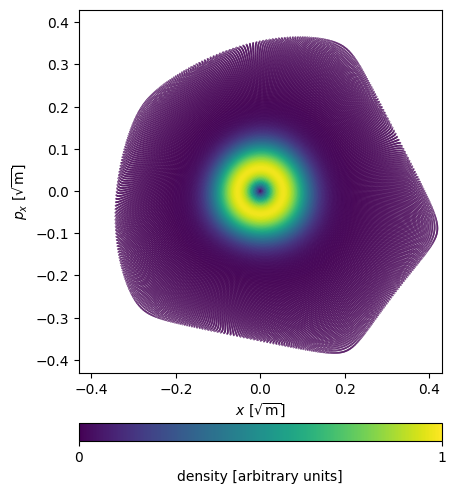

In [66]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.scatter(my_Q, my_P, c=average_weights, cmap='viridis',  marker='o',vmin=weights.min(), vmax=weights.max(), s=.1)
# plt.title('After filamentation')
plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$');
plt.ylabel(r'$p_x\  [\sqrt{\mathrm{m}}]$')
ax = plt.gca()
ax.set_xlim(-0.43, 0.43)
ax.set_ylim(-0.43, 0.43)
ax.set_aspect('equal')
ax.set_box_aspect(1)
divider = make_axes_locatable(ax)
cax = divider.append_axes('bottom', size='5%', pad=0.5)
cbar = fig.colorbar(sc, cax=cax, orientation='horizontal',
                    label='density [arbitrary units]')
cbar.set_ticks([weights.min(), weights.max()])
cbar.set_ticklabels(['0', '1'])
plt.savefig('../plots/average_density_gaussian_filamented.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_1559182/4242327788.py:66: RuntimeWarning: divide by zero encountered in log10
  plt.step(x_centers, np.log10(proj), where='mid', label=label)
/tmp/ipykernel_1559182/4242327788.py:109: RuntimeWarning: divide by zero encountered in log10
  plt.step(x_centers, np.log10(proj), where='mid', label=label, color='k')


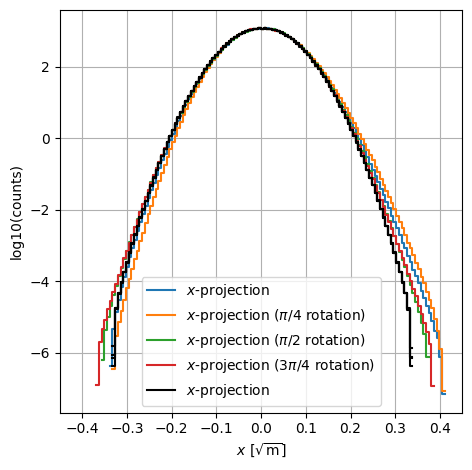

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Example arrays
# X, Y, W are 1D arrays of the same length
# X = ...
# Y = ...
# W = ...

# Bin definitions
my_Q_aux = np.concatenate(Q)
my_P_aux = np.concatenate(P)
my_average_density_aux = np.concatenate(average_weights)

steps = 150
xbins = np.linspace(min(my_Q_aux), max(my_Q_aux), steps)
ybins = np.linspace(min(my_P_aux), max(my_P_aux), steps)

# Build 2D weighted histogram
H, xedges, yedges = np.histogram2d(my_Q_aux, my_P_aux, bins=[xbins, ybins], weights=my_average_density_aux)

# Projection on X: sum over Y bins
projXX = H.sum(axis=1)

# Projection on Y: sum over X bins
projYY = H.sum(axis=0)

# Plot projections

#plt.step(xedges[:-1], projXX, where='mid')


my_Q_aux = np.concatenate(Q)
my_P_aux = np.concatenate(P)
my_density_aux = np.concatenate(weights)
xbins = np.linspace(-0.45, 0.45, steps)
ybins = np.linspace(-0.45, 0.45, steps)

# Build 2D weighted histogram
H, xedges, yedges = np.histogram2d(my_Q_aux, my_P_aux, bins=[xbins, ybins], weights=my_density_aux)

# Projection on X: sum over Y bins
projX = H.sum(axis=1)

# Projection on Y: sum over X bins
projY = H.sum(axis=0)

rotations = [
    (0,           r'$x$-projection'),
    (np.pi/4,     r'$x$-projection ($\pi/4$ rotation)'),
    (np.pi/2,     r'$x$-projection ($\pi/2$ rotation)'),
    (3*np.pi/4,   r'$x$-projection ($3\pi/4$ rotation)'),
]
proj_list = []
for theta, label in rotations:
    QQ = Q*np.cos(theta) - P*np.sin(theta)
    PP = Q*np.sin(theta) + P*np.cos(theta)
    H, xedges, _ = np.histogram2d(np.concatenate(QQ), np.concatenate(PP),
                                   bins=[xbins, ybins], weights=my_average_density_aux, density=True)
    proj_list.append((H.sum(axis=1), label))


# Plot projections
x_centers = xedges[1:]
for proj, label in proj_list:
    plt.step(x_centers, np.log10(proj), where='mid', label=label)
    
# Abel transform of a uniform disk of radius annulus_outer
R = annulus_outer
x_abel = np.linspace(-R, R, 1000)
p_abel = 2 * np.sqrt(np.maximum(R**2 - x_abel**2, 0))
# Normalise to the same integral as the filamented projection
norm = np.trapz(proj_list[0][0], x_centers) / np.trapz(p_abel, x_abel)
#plt.plot(x_abel, p_abel * norm, 'k--', lw=1.5, label=r'Analytical $x$-projection (Abel transform)')

# plt.title("Projection on X")
# plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
# plt.ylabel("Weighted counts")

# plt.tight_layout()
# plt.grid()
# plt.legend()

# my_Q_aux = np.concatenate(Q)
# my_P_aux = np.concatenate(P)
my_density_aux = np.concatenate(weights)

# steps = 150
# xbins = np.linspace(min(my_Q_aux), max(my_Q_aux), steps)
# ybins = np.linspace(min(my_P_aux), max(my_P_aux), steps)

rotations = [
    (0,           r'$x$-projection'),
    (np.pi/4,     ''),
    (np.pi/2,     ''),
    (3*np.pi/4,   ''),
]

proj_list = []
for theta, label in rotations:
    QQ = Q*np.cos(theta) - P*np.sin(theta)
    PP = Q*np.sin(theta) + P*np.cos(theta)
    H, xedges, _ = np.histogram2d(np.concatenate(QQ), np.concatenate(PP),
                                   bins=[xbins, ybins], weights=my_density_aux, density=True)
    proj_list.append((H.sum(axis=1), label))

x_centers = xedges[1:]
for proj, label in proj_list:
    plt.step(x_centers, np.log10(proj), where='mid', label=label, color='k')


plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
plt.ylabel("log10(counts)")
plt.tight_layout()
plt.grid()
plt.legend()
plt.xlim(-0.45, 0.45)
ax = plt.gca()
ax.set_box_aspect(1)
plt.savefig('../plots/projection_x_final_gaussian.pdf', dpi=300, bbox_inches='tight')


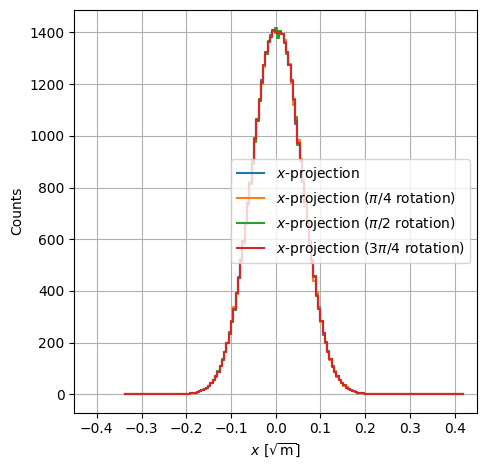

In [50]:
import numpy as np
import matplotlib.pyplot as plt

my_Q_aux = np.concatenate(Q)
my_P_aux = np.concatenate(P)
my_density_aux = np.concatenate(weights)

steps = 150
xbins = np.linspace(min(my_Q_aux), max(my_Q_aux), steps)
ybins = np.linspace(min(my_P_aux), max(my_P_aux), steps)

rotations = [
    (0,           r'$x$-projection'),
    (np.pi/4,     r'$x$-projection ($\pi/4$ rotation)'),
    (np.pi/2,     r'$x$-projection ($\pi/2$ rotation)'),
    (3*np.pi/4,   r'$x$-projection ($3\pi/4$ rotation)'),
]

proj_list = []
for theta, label in rotations:
    QQ = Q*np.cos(theta) - P*np.sin(theta)
    PP = Q*np.sin(theta) + P*np.cos(theta)
    H, xedges, _ = np.histogram2d(np.concatenate(QQ), np.concatenate(PP),
                                   bins=[xbins, ybins], weights=my_density_aux, density=True)
    proj_list.append((H.sum(axis=1), label))

x_centers = xedges[1:]
for proj, label in proj_list:
    plt.step(x_centers, proj, where='mid', label=label)


# plt.title("Projection on X")
plt.xlabel(r'$x\ [\sqrt{\mathrm{m}}]$')
plt.ylabel("Counts")
plt.tight_layout()
plt.grid()
plt.legend()
plt.xlim(-0.45, 0.45)
ax = plt.gca()
ax.set_box_aspect(1)

In [ ]:
# Density as a function of action
# weights[ii, jj] = annulus_mask * cell_area  →  sum over angles gives the
# total area-weighted contribution of torus ii inside the annulus.

Ix_values = np.array([tori[i].Ix for i in range(x_tori_number)])

# Total weight per action shell (sum over angular cells)
density_action = weights.sum(axis=1)

# Normalise by the action-shell width to get density per unit action
dI = np.diff(Ix_values)
Ix_mid = 0.5 * (Ix_values[:-1] + Ix_values[1:])
density_per_dI = 0.5 * (density_action[:-1] + density_action[1:]) / dI

# Reference: uniform disk → constant density in action (∝ 2π ρ₀)
uniform_level = density_per_dI[density_per_dI > 0].mean()

fig, ax = plt.subplots()
ax.plot(Ix_mid, density_per_dI, '.-', color='C0', label=r'$\rho(I)$ (mesh)')
ax.axhline(uniform_level, color='k', ls='--', lw=1.2,
           label=f'Uniform disk reference ({uniform_level:.3g})')
ax.set_xlabel(r'Action $I_x$  [m]')
ax.set_ylabel(r'$\rho(I) = \sum_\theta w / \Delta I$  [a.u.]')
ax.set_title('Density as a function of action')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()


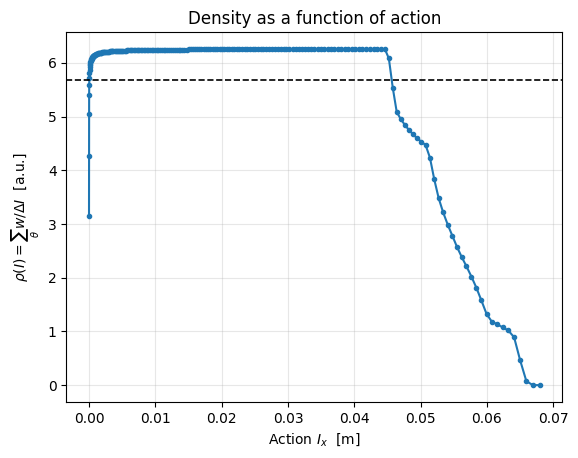

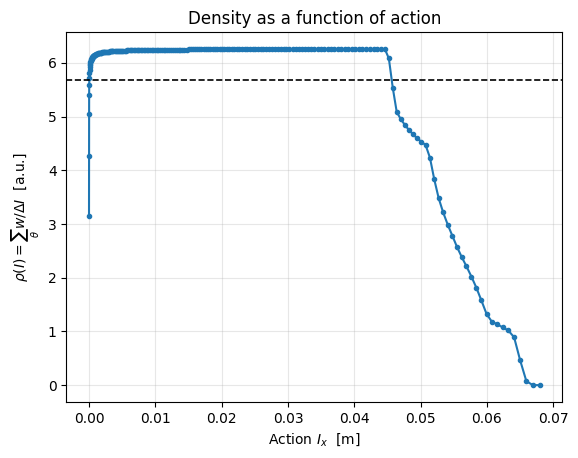